In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import astropy
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _eventISAPhase(session,n_bins=100,shuffle=0):

    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval',load_spikes=False)
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    if on.size == 0:
        return None
    events, is_isa = isru.loadHpcPfcEvents(session,isa=isa)
    events = {e: events[e][is_isa[e],None] for e in events} # keep only events in ISA
    isa_phase, on_fraction = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy

    # shuffle events
    if shuffle > 0:
        for e in events:
            sss = fma.general.shuffleEvents(events[e],n=shuffle,intervals=isa)
            events[e] = np.column_stack((events[e],sss))

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    #event_phase = {e: np.full_like(events[e],np.nan) for e in events}
    event_phase = {e: np.interp(events[e],isa_phase[:,0],isa_phase[:,1]) for e in events} # {event name: (event, shuffle)}
    dist = np.full((len(events),n_bins,shuffle+1),np.nan) # (event, phase, shuffle)
    dist_transformed = np.full((len(events),n_bins,shuffle+1),np.nan)
    p = np.full((len(events),2,shuffle+1),np.nan)
    for i, e in enumerate(events):
        #this_phases = []
        #if len(events[e]) > 0:
        #    this_phases = np.interp(events[e],isa_phase[:,0],isa_phase[:,1])
        #    event_phase[e] = this_phases
        for k in range(shuffle+1):
            this_phases = event_phase[e][:,k]
            d, _ = np.histogram(this_phases,bins=bins,density=True)
            dist[i,:,k] = d

            # CDF transform, let F(phi) be the empirical CDF of ISA phase
            u = np.searchsorted(isa_phase_sorted,this_phases,side="right") / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
            p[i,:,k] = astropy.stats.kuiper(u)
            u = u * 2 * np.pi # transformed phase, uniform if events are uniform w.r.t. ISA phase
            dist_transformed[i,:,k] = np.histogram(u,bins=bins,density=True)[0]

    # make distributions walk the full circle
    centers = np.append(centers,centers[-1]+centers[1]-centers[0])
    tuning_curve = dist / isa_dist[None,:,None]
    dist = np.concatenate((dist,dist[:,0:1]),axis=1)
    tuning_curve = np.concatenate((tuning_curve,tuning_curve[:,0:1]),axis=1)
    dist_transformed = np.concatenate((dist_transformed,dist_transformed[:,0:1]),axis=1)

    dist = xr.DataArray(dist,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    tuning_curve = xr.DataArray(tuning_curve,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    dist_transformed = xr.DataArray(dist_transformed,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)}) # 'p': ('event', p),
    p = xr.DataArray(p,dims=['ev','val','shuf'],coords={'ev': list(events.keys()), 'val': ['D','p'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return event_phase, dist, tuning_curve, dist_transformed, p, isa_phase

In [14]:
session = fma.data.readBatchFile(batch_file)[0][5]
print(session)
event_phase, dist, tuning_curve, dist_transformed, p, isa_phase = _eventISAPhase(session,n_bins=60,shuffle=15)

/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml


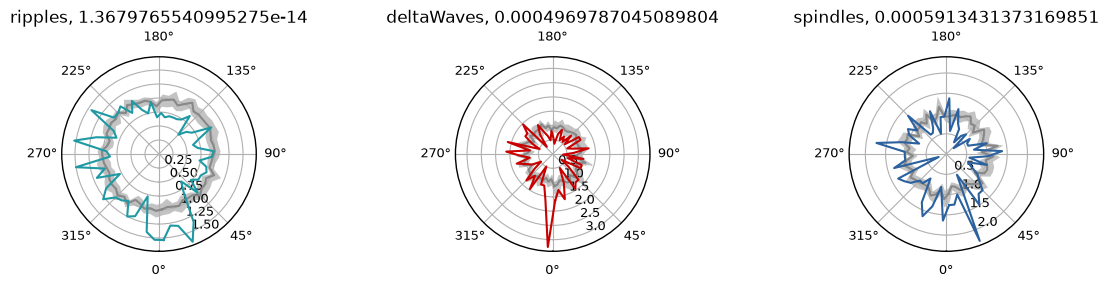

In [15]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(event_phase):
    tc = tuning_curve.sel(ev=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, {p.sel(ev=e,val='p',shuf=False).values}')
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(tuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(e))

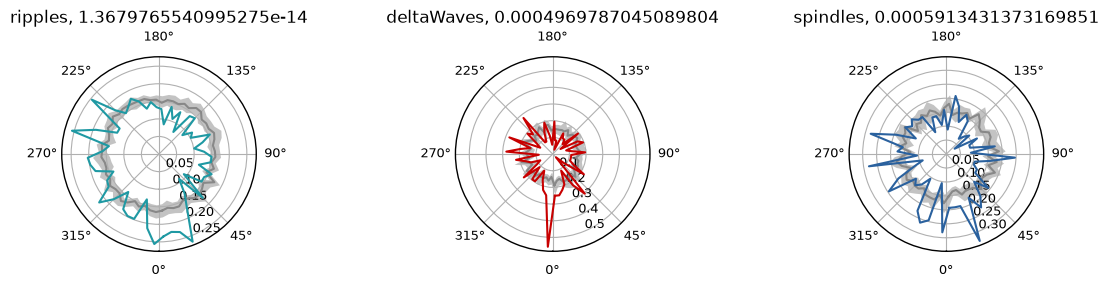

In [16]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(event_phase):
    tc = dist_transformed.sel(ev=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, {p.sel(ev=e,val='p',shuf=False).values}')
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(tuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(e))

Runa batch

In [10]:
event_phase, dist, tuning_curve, dist_transformed, p, isa_phase = fma.data.runBatch(batch_file,_eventISAPhase,kwargs={'n_bins': 50, 'shuffle': 1000},parallel=True)
dist_transformed_cat = xr.concat([d for d in dist_transformed if d is not None],dim='rat',join='outer')
dist_transformed_avg = dist_transformed_cat.groupby('rat').mean(dim='rat',skipna=True)
tuning_curve_cat = xr.concat([d for d in tuning_curve if d is not None],dim='rat',join='outer')
tuning_curve_avg = tuning_curve_cat.groupby('rat').mean(dim='rat',skipna=True)
p = xr.concat([d for d in p if d is not None],dim='rat',join='outer')


Starting Batch, 2026-07-09 16:46:00.356292 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230818/Rat002_20230818.xml (37)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230820/Rat002_20230820.xml (39)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230821/Rat002_20230821.xml (40)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-129

In [7]:
# test
p_val = {e: fma.analysis.maxStatisticTest(p.sel(ev='ripples',val='D',shuf=False).values[:,None], p.sel(ev='ripples',val='D',shuf=True).values[:,None], group=p.rat)
         for e in p.ev.values}

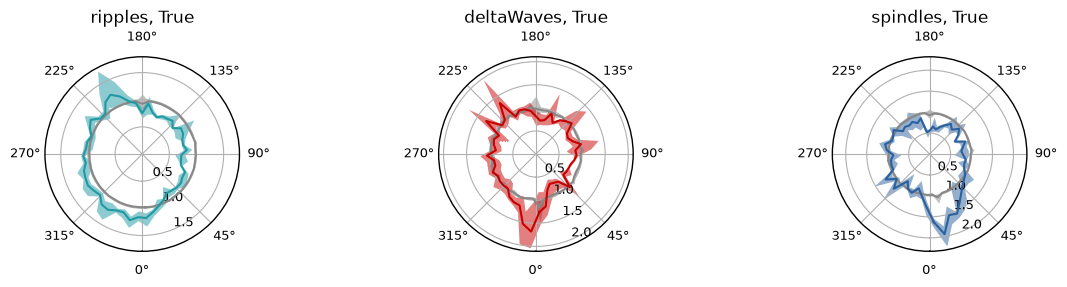

In [24]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(tuning_curve_avg.ev.values):
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, {p_val[e].item()}')
    tc = tuning_curve_avg.sel(ev=e)
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).mean(dim='shuf'),color=isru.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=False),color=isru.paperColors(e),ax=ax[i])

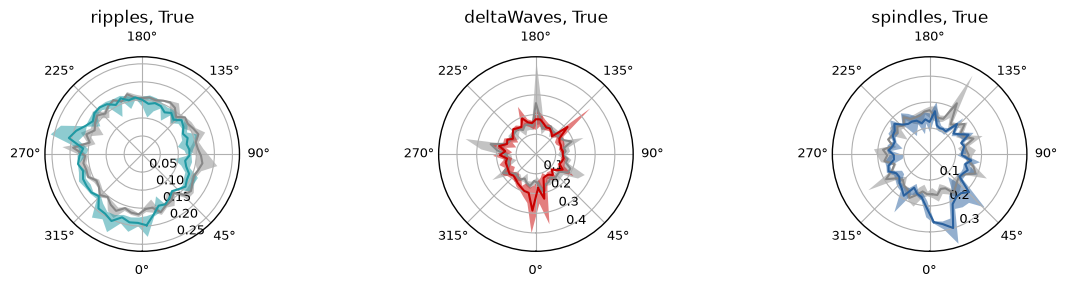

In [18]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(dist_transformed_avg.ev.values):
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, {p_val[e].item()}')
    tc = dist_transformed_avg.sel(ev=e)
    fma.plotting.semPlot(tc.phi,tc.isel(shuf=5),color=isru.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=False),color=isru.paperColors(e),ax=ax[i])

Test ISPhase

In [8]:
def _ISAPhase(session):

    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval',load_spikes=False)
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    isa_phase = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa)

    return isa, on, isa_phase

In [9]:
session = fma.data.readBatchFile(batch_file)[0][30]
print(session)
isa, on, isa_phase = _ISAPhase(session)

/mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


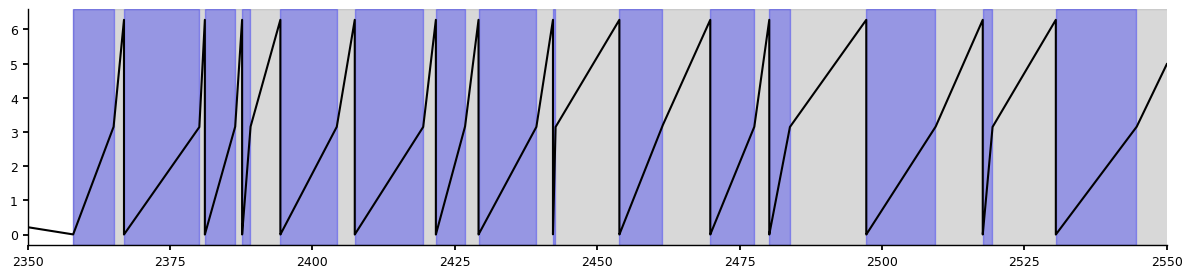

In [10]:
fig, ax = fma.plotting.makeFigure(size=(30,7))
fma.plotting.plotXY(isa_phase,ax=ax[0],color='k')
fma.plotting.plotIntervals(isa,ax=ax[0])
fma.plotting.plotIntervals(on,color='b',ax=ax[0])
ax[0].set(xlim=[2350,2550]);

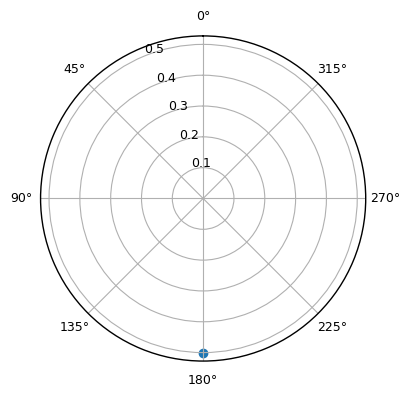

In [27]:
fig, ax = fma.plotting.makeFigure(projection='polar')
ax[0].set_theta_zero_location('N')
ax[0].scatter(np.pi,0.5)